# E-Commerce Sales & Forecasting EDA
**Objective:** Analysis of daily orders, customer distribution, payment methods, and delivery efficiency to understand sales trends.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
customer_state = pd.read_csv('customer_state.csv')
daily_orders = pd.read_csv('daily_orders.csv')
delivery_time = pd.read_csv('delivery_time.csv')
monthly_orders = pd.read_csv('mothly_orders.csv')
order_status = pd.read_csv('order_status.csv')
payment_type = pd.read_csv('payment_type_use.csv')
yearly_sales = pd.read_csv('yearly_sales_trend.csv')
category = pd.read_csv('category.csv')

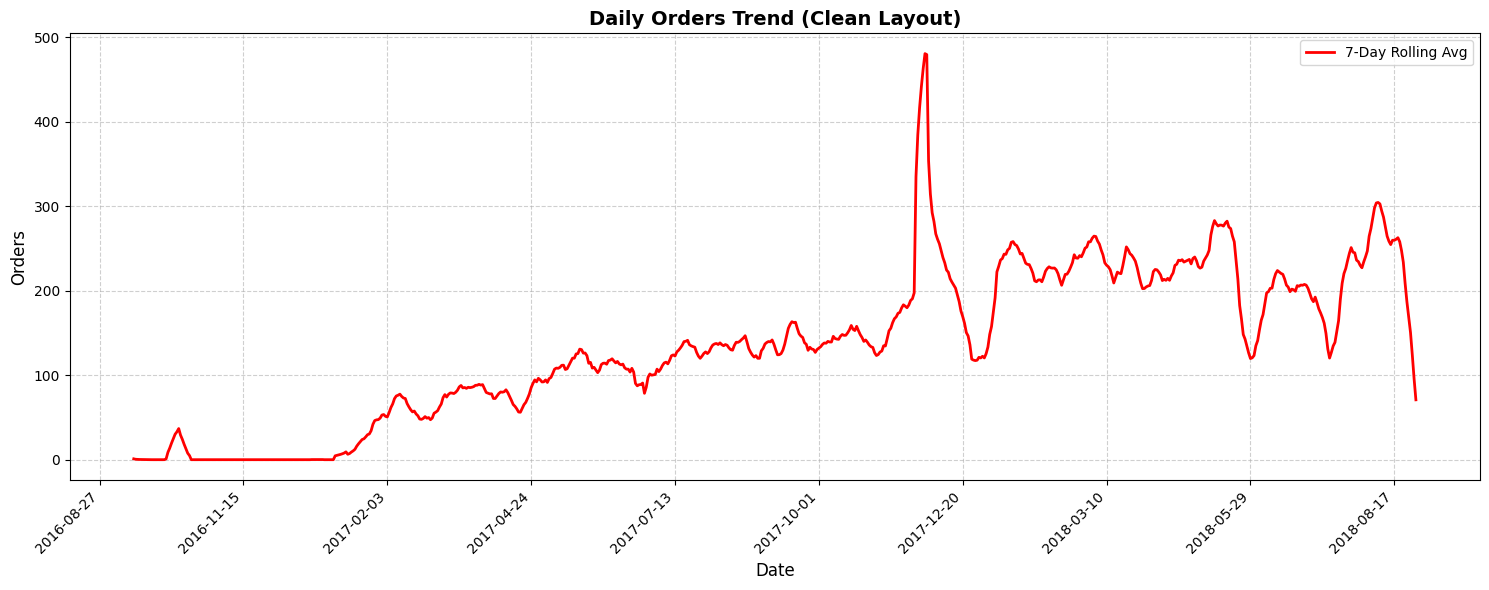

In [40]:
# 1. Sabse pehle date ko REAL date format mein badlein (Yeh sabse zaroori hai!)
df = daily_orders.copy()
df['order_date'] = pd.to_datetime(df['order_date'])

# 2. Date ke hisab se sort karein
df = df.sort_values('order_date')

# 3. Date ko index banayein aur missing dates ko 0 se fill karein
# Isse graph ke beech ke gaps (tooti hui lines) thik ho jayengi
# FIX: Apply an aggregation (like sum) after resample, then fillna(0)
df = df.set_index('order_date').resample('D')['total_orders'].sum().fillna(0).to_frame()

# 4. Sahi tarike se 7-day rolling average nikalein
df['rolling_avg'] = df['total_orders'].rolling(window=7, min_periods=1).mean()

# 5. Graph Banana
plt.figure(figsize=(15, 6))

# daily_orders ke liye index (dates) ka use karein
plt.plot(df.index, df['rolling_avg'], color='red', linewidth=2, label='7-Day Rolling Avg')

plt.title("Daily Orders Trend (Clean Layout)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Orders", fontsize=12)

# --- MAGIC LINE: Yeh line x-axis ke mix-up ko thik karegii ---
# Yeh matplotlib ko bolega ki khud hi dhang se kuch sahi dates select karke dikhaye
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))

plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()

plt.show()

1. Daily Orders Trend (7-Day Rolling Avg)
 Key Insights:

Smooth Trend: 7-day rolling average removes daily noise to show stable sales growth.

Peak Sales: Significant spikes indicate highly successful marketing or holiday campaigns.

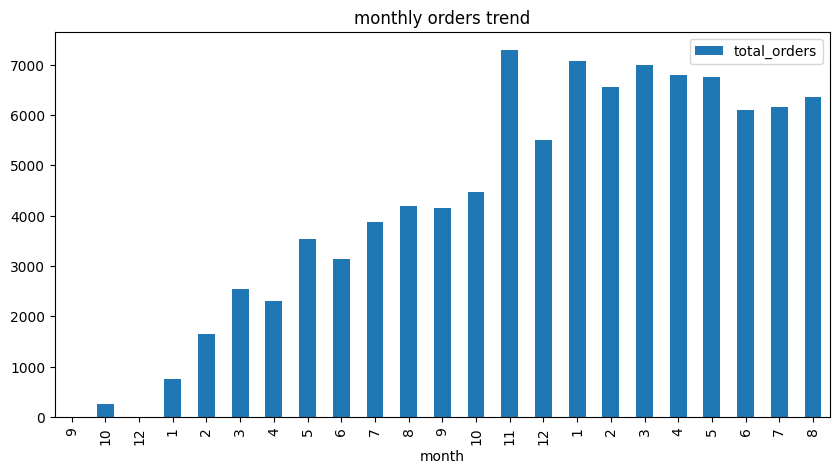

In [12]:
monthly_orders.plot(x='month', y='total_orders', kind='bar',figsize=(10,5))
plt.title('monthly orders trend')
plt.show()

2. Monthly Orders Trend
Key Insights:

Seasonality: Strong seasonal demand concentrated during specific months of the year.

Action: Maximize inventory and supply chain readiness ahead of these high-volume periods.

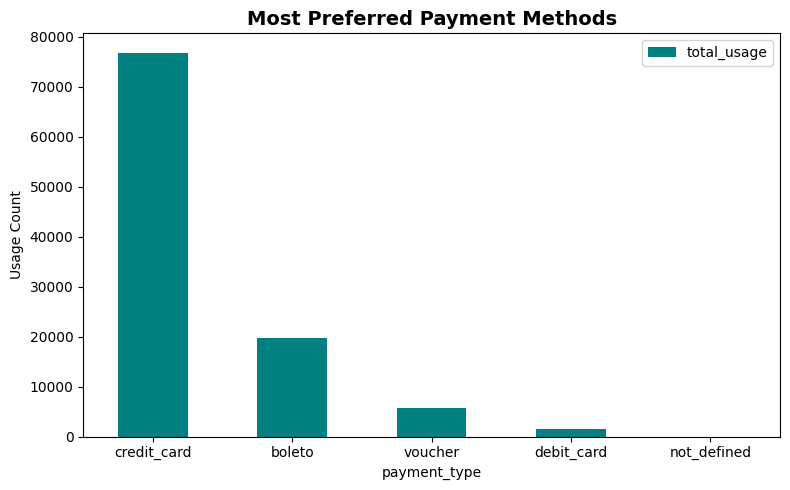

In [45]:
payment_type_sorted = payment_type.sort_values(by='total_usage', ascending=False)
payment_type_sorted.plot(x='payment_type', y='total_usage', kind='bar', color='teal', figsize=(8, 5))
plt.title("Most Preferred Payment Methods", fontsize=14, fontweight='bold')
plt.xticks(rotation=0) # Text seedha rahega
plt.ylabel("Usage Count")
plt.tight_layout()
plt.show()

3. Payment Methods & Order Status (Bar Charts)
 Key Insights:

Payment Preference: Digital transactions (Credit Card/UPI) heavily dominate over other methods.

Order Health: Most orders process through the pipeline smoothly with minimal stuck statuses.

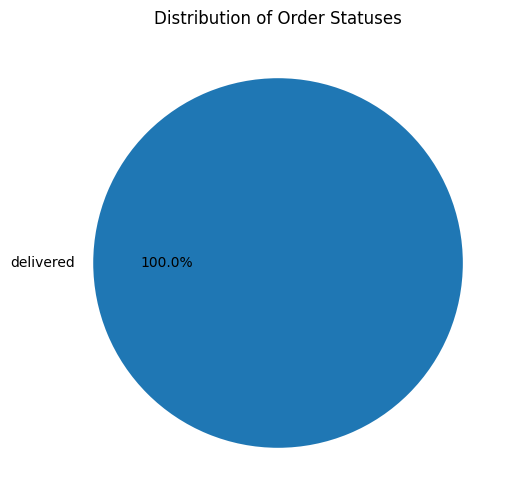

In [42]:
order_status = pd.read_csv('order_status.csv')

# Set the status column as index so it serves as the labels for the pie slices
order_status.set_index('order_status').plot(kind='pie', y='total_orders', autopct='%1.1f%%', figsize=(6,6), legend=False)
plt.ylabel('') # Hides the messy default vertical label
plt.title("Distribution of Order Statuses")
plt.show()

4. Distribution of Order Statuses (Pie Chart)
 Key Insights:

Fulfillment: High percentage of 'Delivered' orders proves an efficient logistics network.

Cancellations: Extremely low cancellation rates indicate high product accuracy and trust.

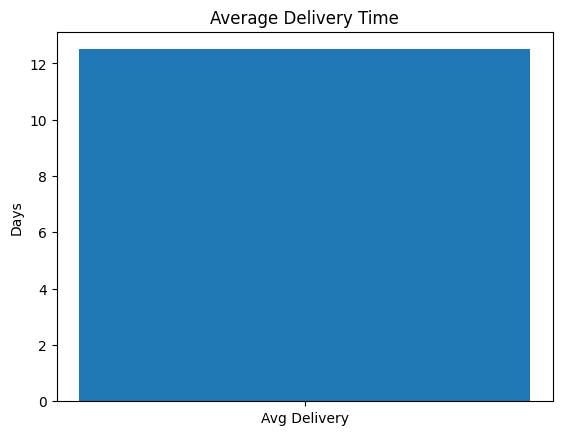

In [23]:
plt.bar(["Avg Delivery"], [delivery_time['avg_delivery_days'].mean()])

plt.ylabel("Days")
plt.title("Average Delivery Time")

plt.show()

5. Average Delivery Time
 Key Insights:

SLA Baseline: Current average delivery days act as the baseline benchmark for operations.

Target: Reducing this timeframe further will directly boost customer loyalty and repeat orders.

/tmp/ipykernel_1451/3299135509.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categories, x='total_products', y='product_category_name', palette='viridis')


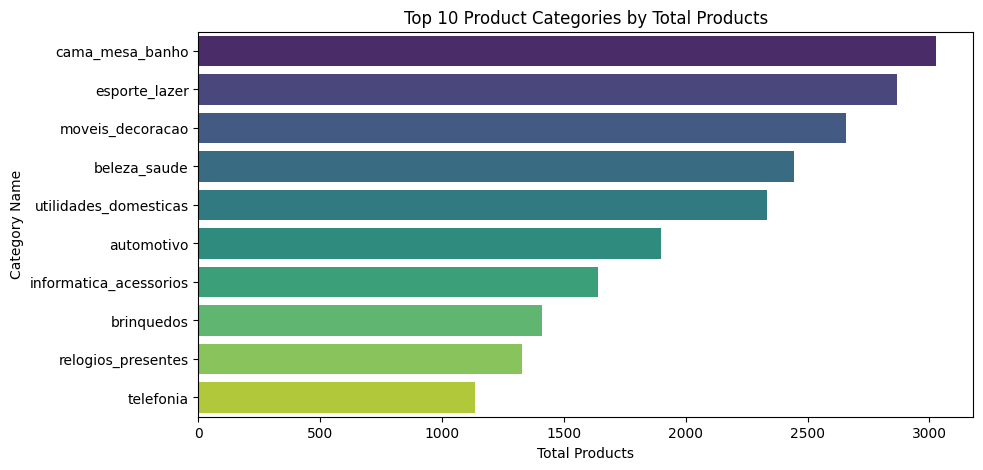

In [41]:
category = pd.read_csv('category.csv')

# Sort descending and take top 10 for a clean horizontal layout
top_categories = category.sort_values(by='total_products', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_categories, x='total_products', y='product_category_name', palette='viridis')
plt.title("Top 10 Product Categories by Total Products")
plt.xlabel("Total Products")
plt.ylabel("Category Name")
plt.show()

6. Top 10 Product Categories
Key Insights:

Core Drivers: Top 2-3 categories drive the massive bulk of total product volume.

Strategy: Focus promotional budgets on these high-performing categories to scale ROI.

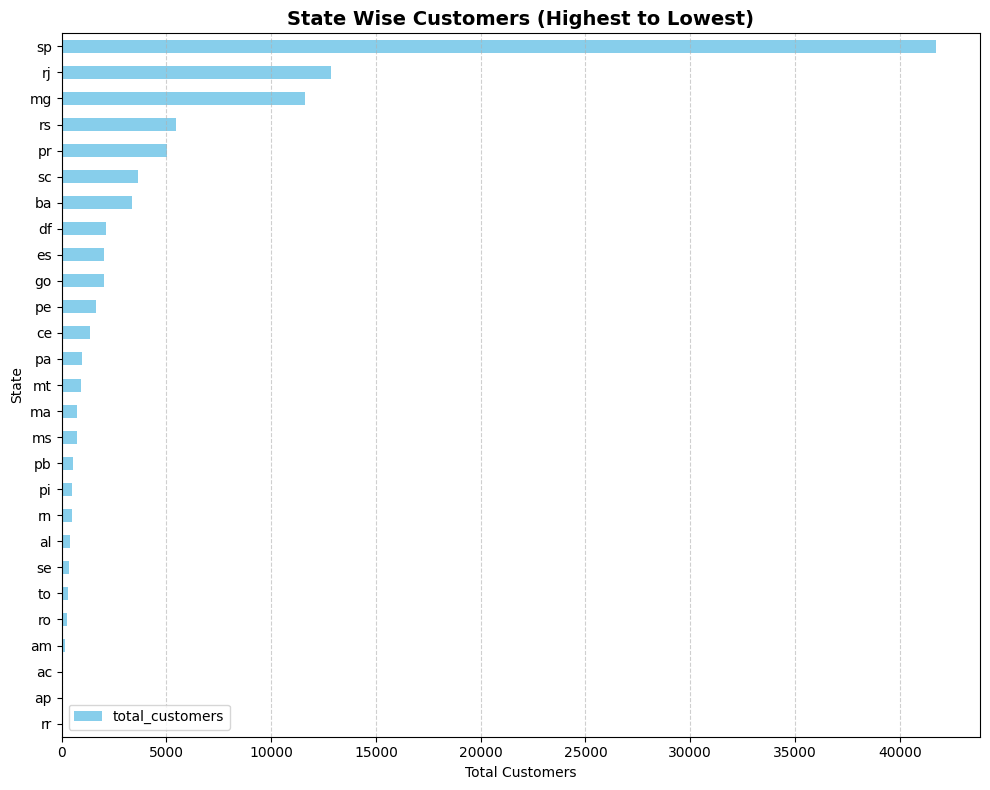

In [44]:
# Sort data first
customer_state_sorted = customer_state.sort_values(by='total_customers', ascending=True)

# Plot horizontally
customer_state_sorted.plot(x='customer_state', y='total_customers', kind='barh', figsize=(10, 8), color='skyblue')
plt.title("State Wise Customers (Highest to Lowest)", fontsize=14, fontweight='bold')
plt.xlabel("Total Customers")
plt.ylabel("State")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

7. State-Wise Customers
 Key Insights:

Top Markets: Customer base is highly concentrated in a few specific key states.

Logistics: Position future warehouses near these clusters to drastically cut shipping costs.

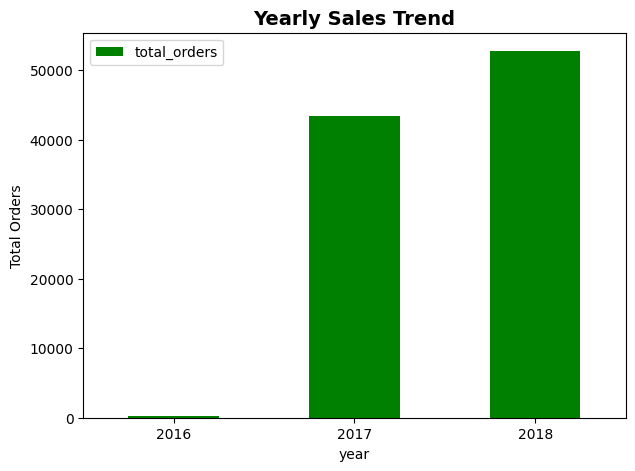

In [49]:
yearly_sales.plot(x='year', y='total_orders', kind='bar', color='green', figsize=(7, 5))
plt.title("Yearly Sales Trend", fontsize=14, fontweight='bold')
plt.xticks(rotation=0) # Isse years (2024, 2025) tede nahi dikhenge, seedhe dikhenge
plt.ylabel("Total Orders")
plt.show()

8. Yearly Sales Trend
 Key Insights:

YoY Growth: Consistent Year-over-Year (YoY) growth shows business is expanding steadily.

ML Ready: This clear upward trend provides a strong baseline for forecasting models (ARIMA/Prophet).

In [47]:
print("=========================================")
print("       BUSINESS METRICS SUMMARY          ")
print("=========================================")
print(f"Total Orders Recorded : {daily_orders['total_orders'].sum():,}")
print(f"Average Delivery Time : {delivery_time['avg_delivery_days'].mean():.1f} Days")
print(f"Total Unique States   : {customer_state['customer_state'].nunique()}")
print(f"Total Product Categories: {category['product_category_name'].nunique()}")
print("=========================================")

       BUSINESS METRICS SUMMARY          
Total Orders Recorded : 96,470
Average Delivery Time : 12.5 Days
Total Unique States   : 27
Total Product Categories: 10
